# Análise Exploratória de Dados: Investimento em Transferências e Desempenho Esportivo nas Cinco Grandes Ligas Europeias de Futebol

**Disciplina:** Análise Estatística Exploratória
**Dataset:** [Player Scores — davidcariboo](https://www.kaggle.com/datasets/davidcariboo/player-scores) (Kaggle / dados extraídos do Transfermarkt)

## Contexto

O mercado de transferências no futebol movimenta bilhões de euros por temporada. Uma pergunta recorrente entre torcedores, jornalistas e analistas esportivos é: **o quanto um clube gasta em contratações realmente se traduz em desempenho esportivo?**

Este trabalho realiza uma **análise estatística exploratória** (sem uso de Machine Learning ou modelos preditivos) sobre o mercado de transferências e o desempenho esportivo dos principais clubes das cinco principais ligas nacionais da Europa:

- Premier League (Inglaterra)
- La Liga (Espanha)
- Serie A (Itália)
- Bundesliga (Alemanha)
- Ligue 1 (França)

Os IDs exatos dessas competições no dataset **serão confirmados via `competitions.csv`** antes de qualquer filtro — não assumimos IDs de antemão.


## Objetivo

Este projeto tem como objetivo investigar a relação entre o investimento realizado em contratações de jogadores e o desempenho esportivo dos principais clubes das cinco principais ligas nacionais da Europa: Premier League, La Liga, Serie A, Bundesliga e Ligue 1.

A análise será realizada utilizando dados públicos do Transfermarkt, disponibilizados pelo dataset `Football Data from Transfermarkt`, do Kaggle. A unidade de análise será o clube em uma determinada temporada.

Serão analisados:

- o investimento total em contratações;
- o número de jogadores contratados;
- os pontos conquistados por jogo;
- o saldo de gols por jogo;
- a posição final na liga, quando disponível;
- a desigualdade de investimento e de desempenho entre os principais clubes de cada liga e temporada.

O projeto realizará o pré-processamento dos dados, incluindo o tratamento de valores ausentes, duplicidades, conversão de tipos e integração entre diferentes tabelas. Em seguida, serão aplicadas medidas estatísticas de centralização, posição e dispersão, além de análises de correlação e visualizações gráficas.

O objetivo é identificar padrões e associações entre o investimento em transferências e o desempenho esportivo, sem afirmar relações de causalidade. Também serão apresentadas as limitações dos dados, especialmente a existência de valores de transferências não divulgados e a utilização de valores financeiros nominais.

## Perguntas

### Pergunta 1: Distribuição do Investimento e das Contratações

**Pergunta:** Como se distribuem o investimento total e o número de contratações dos clubes em cada temporada, e quão diferentes são esses valores entre os clubes?

**Motivo da escolha:** Antes de testar qualquer relação causal ou correlação, é preciso entender o comportamento básico dos dados — se o investimento é concentrado em poucos clubes ou distribuído de forma mais equilibrada. Essa é a base para interpretar corretamente as Perguntas 2 e 3.

**Hipótese 1:** Os investimentos são bastante desiguais entre os clubes, com poucos times apresentando gastos muito elevados, fazendo com que a média de investimento seja superior à mediana.

**Relação com o database:** Utiliza `total_investment_eur` (agregado por `club_id` + `season_start_year` a partir de `transfers.csv`) e `number_of_signings`, calculados na Seção 8 (`agregado_investimento`) e presentes na base final (Seção 10).

**Métricas estatísticas:** Medidas de centralização (média, mediana, moda), quartis (Q1, Q3), medidas de dispersão (desvio padrão, variância, amplitude, coeficiente de variação) e correlação (Pearson/Spearman) entre investimento total e número de contratações.

### Pergunta 2: Investimento x Desempenho Esportivo

**Pergunta:** Existe correlação entre o total investido em contratações por um clube em uma temporada e seu desempenho ao final da competição?

**Motivo da escolha:** É a pergunta central do projeto: testar se o investimento em contratações é um preditor do desempenho esportivo, sem afirmar causalidade — o resultado pode refletir tanto o efeito do investimento quanto causalidade reversa (sucesso gera receita, que gera investimento).

**Hipótese 2:** Clubes que investem mais tendem a obter mais pontos e melhores posições finais, porém a correlação não é perfeita, pois outros fatores também influenciam o desempenho.

**Relação com o database:** Cruza `total_investment_eur` (Seção 8) com as métricas de desempenho calculadas na Seção 9 — `points_per_game`, `goal_difference_per_game` e `final_position` (quando disponível) — unidas na base final por `club_id` + `season_start_year` (Seção 10).

**Métricas estatísticas:** Medidas de centralização e dispersão de investimento e desempenho, quartis (para comparar grupos de alto e baixo investimento) e correlação (Pearson/Spearman) entre investimento e cada métrica de desempenho.

### Pergunta 3: Desigualdade de Investimento x Desigualdade de Desempenho

**Pergunta:** Ligas com maior desigualdade de investimento entre seus clubes também apresentam maior desigualdade de desempenho entre os times?

**Motivo da escolha:** Muda a unidade de análise de clube para liga inteira, investigando se a concentração financeira se traduz em desequilíbrio competitivo — um tema ligado a debates reais sobre "competitive balance" no esporte.

**Hipótese 3:** Quanto maior a dispersão dos investimentos entre os clubes de uma liga, maior tende a ser a dispersão dos pontos obtidos, indicando maior desigualdade competitiva.

**Relação com o database:** Agrega `total_investment_milhoes` e `points_per_game` por `league_name` + `season_start_year` (Seção 14, `dispersao_liga_temporada`), calculando o desvio padrão de cada variável dentro de cada liga-temporada.

**Métricas estatísticas:** Normalização/padronização (Z-score) das medidas de dispersão entre liga-temporadas, e correlação (Pearson/Spearman) entre a dispersão do investimento e a dispersão do desempenho.

**Escopo da amostra:** Nesta versão, "principais clubes" significa todos os clubes que disputaram as cinco primeiras divisões selecionadas nas temporadas completas da janela analisada. Não há um filtro adicional por ranking ou tamanho do clube; se o grupo decidir estudar apenas um subconjunto, deverá definir esse critério antes de recalcular as métricas.

## 4. Bibliotecas e Carregamento dos Dados

O dataset `davidcariboo/player-scores` contém **múltiplos arquivos CSV relacionados** (transferências, jogos, clubes, competições etc.). Por isso, **não** usamos `kagglehub.load_dataset(..., file_path="")` como se houvesse uma única tabela — em vez disso, baixamos o diretório completo do dataset com `kagglehub.dataset_download()` e carregamos cada CSV necessário com `pandas`.


In [1]:
# Instalação das dependências necessárias (Google Colab já traz pandas/numpy/matplotlib/scipy)
!pip install -q kagglehub


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import kagglehub

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
# Usa o snapshot versionado em dados/ quando o notebook está na raiz do projeto.
# No Colab (sem a pasta local), baixa o diretório completo do Kaggle como fallback.
dados_locais = os.path.join(os.getcwd(), "dados")
arquivos_minimos = ["transfers.csv", "games.csv", "club_games.csv", "clubs.csv", "competitions.csv"]
if all(os.path.exists(os.path.join(dados_locais, f)) for f in arquivos_minimos):
    dataset_path = dados_locais
    print("Usando snapshot local em dados/.")
else:
    dataset_path = kagglehub.dataset_download("davidcariboo/player-scores")
    print("Snapshot local não encontrado; dataset baixado do Kaggle.")
print("Diretório local do dataset:", dataset_path)

arquivos_encontrados = sorted(os.listdir(dataset_path))
print("\nArquivos encontrados no dataset:")
for f in arquivos_encontrados:
    caminho = os.path.join(dataset_path, f)
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f" - {f} ({tamanho_mb:.2f} MB)")


Usando snapshot local em dados/.
Diretório local do dataset: /Users/godoy/Desktop/Projetos/projeto-estatistica/dados

Arquivos encontrados no dataset:
 - club_games.csv (14.06 MB)
 - clubs.csv (0.20 MB)
 - competitions.csv (0.01 MB)
 - games.csv (27.62 MB)
 - transfers.csv (17.27 MB)


In [4]:
# Carregamento das tabelas que esperamos precisar. Os nomes serão confirmados
# na inspeção da seção 5 - se algum arquivo não existir com esse nome exato,
# ajustamos a leitura para o nome real encontrado em `arquivos_encontrados`.

def carregar_csv(nome_arquivo):
    caminho = os.path.join(dataset_path, nome_arquivo)
    if not os.path.exists(caminho):
        print(f"[AVISO] Arquivo não encontrado com o nome esperado: {nome_arquivo}")
        return None
    return pd.read_csv(caminho)

transfers = carregar_csv("transfers.csv")
games = carregar_csv("games.csv")
club_games = carregar_csv("club_games.csv")
clubs = carregar_csv("clubs.csv")
competitions = carregar_csv("competitions.csv")

tabelas = {
    "transfers": transfers,
    "games": games,
    "club_games": club_games,
    "clubs": clubs,
    "competitions": competitions,
}

for nome, df in tabelas.items():
    if df is not None:
        print(f"{nome}: shape = {df.shape}")
    else:
        print(f"{nome}: NÃO CARREGADO — verificar nome do arquivo em arquivos_encontrados")


transfers: shape = (175165, 10)
games: shape = (88958, 23)
club_games: shape = (177916, 11)
clubs: shape = (796, 17)
competitions: shape = (65, 11)


## 5. Entendimento do Dataset

Antes de qualquer processamento, inspecionamos a estrutura real de cada tabela: colunas, tipos e primeiras linhas.


In [5]:
def inspecionar(nome, df, n=5):
    print("=" * 80)
    print(f"TABELA: {nome}")
    print("=" * 80)
    print("Shape:", df.shape)
    print("\nColunas e tipos:")
    print(df.dtypes)
    print("\nPrimeiras linhas:")
    display(df.head(n))
    print()

for nome, df in tabelas.items():
    if df is not None:
        inspecionar(nome, df)


TABELA: transfers
Shape: (175165, 10)

Colunas e tipos:
player_id                int64
transfer_date              str
transfer_season            str
from_club_id             int64
to_club_id               int64
from_club_name             str
to_club_name               str
transfer_fee           float64
market_value_in_eur    float64
player_name                str
dtype: object

Primeiras linhas:


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,645842,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,150000.0,Chan-gi An
2,677470,2028-02-02,27/28,6505,3535,Gimcheon Sangmu,Ulsan HD,0.0,400000.0,Yool Heo
3,709155,2028-02-02,27/28,6505,19684,Gimcheon Sangmu,Jeju SK,0.0,325000.0,Jae-hyeok Oh
4,728133,2028-02-02,27/28,6505,35759,Gimcheon Sangmu,Bucheon FC,0.0,175000.0,Sang-hyeok Lee



TABELA: games
Shape: (88958, 23)

Colunas e tipos:
game_id                     int64
competition_id                str
season                      int64
round                         str
date                          str
home_club_id                int64
away_club_id                int64
home_club_goals             int64
away_club_goals             int64
home_club_position        float64
away_club_position        float64
home_club_manager_name        str
away_club_manager_name        str
stadium                       str
attendance                float64
referee                       str
url                           str
home_club_formation           str
away_club_formation           str
home_club_name                str
away_club_name                str
aggregate                     str
competition_type              str
dtype: object

Primeiras linhas:


,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
0,1026846,FIWC,2009,Round of 16,2010-06-26,3449,3589,2,1,NaN,NaN,Óscar Tabárez,Jung-moo Huh,Nelson Mandela Bay Stadium,30597.0,Wolfgang Stark,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Uruguay,South Korea,2:1,national_team_competition
1,1026847,FIWC,2009,Round of 16,2010-06-27,3437,6303,3,1,NaN,NaN,Diego Maradona,Javier Aguirre,FNB-Stadium,84377.0,Roberto Rosetti,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Argentina,Mexico,3:1,national_team_competition
2,1027001,FIWC,2009,Round of 16,2010-06-26,3505,3441,1,2,NaN,NaN,Bob Bradley,Milovan Rajevac,Royal Bafokeng Stadium,34976.0,Viktor Kassai,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,United States,Ghana,1:2,national_team_competition
3,1027002,FIWC,2009,Round of 16,2010-06-27,3262,3299,4,1,NaN,NaN,Joachim Löw,Fabio Capello,Free State Stadium,40510.0,Jorge Larrionda,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Germany,England,4:1,national_team_competition
4,1027048,FIWC,2009,Round of 16,2010-06-28,3379,3503,2,1,NaN,NaN,Bert van Marwijk,Vladimír Weiss,Moses Mabhida Stadion,61962.0,Undiano Mallenco,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Netherlands,Slovakia,2:1,national_team_competition



TABELA: club_games
Shape: (177916, 11)

Colunas e tipos:
game_id                    int64
club_id                    int64
own_goals                  int64
own_position             float64
own_manager_name             str
opponent_id                int64
opponent_goals             int64
opponent_position        float64
opponent_manager_name        str
hosting                      str
is_win                     int64
dtype: object

Primeiras linhas:


,game_id,club_id,own_goals,own_position,own_manager_name,opponent_id,opponent_goals,opponent_position,opponent_manager_name,hosting,is_win
0,1026846,3449,2,NaN,Óscar Tabárez,3589,1,NaN,Jung-moo Huh,Home,1
1,1026846,3589,1,NaN,Jung-moo Huh,3449,2,NaN,Óscar Tabárez,Away,0
2,1026847,3437,3,NaN,Diego Maradona,6303,1,NaN,Javier Aguirre,Home,1
3,1026847,6303,1,NaN,Javier Aguirre,3437,3,NaN,Diego Maradona,Away,0
4,1027001,3441,2,NaN,Milovan Rajevac,3505,1,NaN,Bob Bradley,Away,1



TABELA: clubs
Shape: (796, 17)

Colunas e tipos:
club_id                      int64
club_code                      str
name                           str
domestic_competition_id        str
total_market_value         float64
squad_size                   int64
average_age                float64
foreigners_number            int64
foreigners_percentage      float64
national_team_players        int64
stadium_name                   str
stadium_seats                int64
net_transfer_record            str
coach_name                     str
last_season                  int64
filename                       str
url                            str
dtype: object

Primeiras linhas:


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris FC,FR1,NaN,27,27.2,14,51.9,7,Stade Jean Bouin,19904,€-25.00m,Stéphane Gilli,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,10010,esporte-clube-bahia,Esporte Clube Bahia,BRA1,NaN,32,26.6,9,28.1,3,Arena Fonte Nova,47364,+€8.14m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/esporte-clube-...
3,1003,leicester-city,Leicester City,GB1,NaN,29,25.9,17,58.6,9,King Power Stadium,32259,+€57.30m,Steve Cooper,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/leicester-city...
4,1005,us-lecce,US Lecce,IT1,NaN,39,23.8,36,92.3,10,Ettore Giardiniero,31559,+€3.35m,Eusebio Di Francesco,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...



TABELA: competitions
Shape: (65, 11)

Colunas e tipos:
competition_id              str
competition_code            str
name                        str
sub_type                    str
type                        str
country_id                int64
country_name                str
domestic_league_code        str
confederation               str
total_clubs             float64
url                         str
dtype: object

Primeiras linhas:


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
0,A1,bundesliga,bundesliga,first_tier,domestic_league,127,Austria,A1,europa,12.0,https://www.transfermarkt.co.uk/bundesliga/sta...
1,AFAC,afc-asian-cup,afc-asian-cup,afc_asian_cup,national_team_competition,-1,NaN,NaN,asien,NaN,https://www.transfermarkt.co.uk/afc-asian-cup/...
2,AFCN,africa-cup-of-nations,africa-cup-of-nations,africa_cup_of_nations,national_team_competition,-1,NaN,NaN,afrika,NaN,https://www.transfermarkt.co.uk/africa-cup-of-...
3,ARG1,torneo-apertura,torneo-apertura,first_tier,domestic_league,9,Argentina,ARG1,amerika,30.0,https://www.transfermarkt.co.uk/torneo-apertur...
4,AUS1,a-league-men,a-league-men,first_tier,domestic_league,12,Australia,AUS1,asien,12.0,https://www.transfermarkt.co.uk/a-league-men/s...


### Confirmação das colunas relevantes

Com base na inspeção acima, confirmamos (ou adaptamos) os nomes das colunas que usaremos:

- **transfers**: identificação do jogador, data/temporada da transferência, clube de origem e destino, valor pago (`transfer_fee`).
- **games**: identificação da partida, data, temporada, competição, clubes mandante/visitante e placar.
- **club_games**: uma linha por clube por partida (visão "própria x adversário"), incluindo posição na tabela (`own_position`) quando disponível.
- **clubs**: identificação e nome do clube, e a liga doméstica do clube (`domestic_competition_id`).
- **competitions**: identificação, nome e tipo de cada competição (liga doméstica, copa, torneio continental etc.).

O código abaixo verifica programaticamente se as colunas esperadas existem, e usa esse resultado para guiar o restante da análise (em vez de simplesmente presumir).


In [6]:
colunas_esperadas = {
    "transfers": ["player_id", "transfer_date", "transfer_season", "from_club_id", "to_club_id", "transfer_fee"],
    "games": ["game_id", "date", "season", "competition_id", "home_club_id", "away_club_id", "home_club_goals", "away_club_goals"],
    "club_games": ["game_id", "club_id", "opponent_id", "own_goals", "opponent_goals", "own_position", "is_win"],
    "clubs": ["club_id", "name", "domestic_competition_id"],
    "competitions": ["competition_id", "name", "type", "country_name"],
}

for nome, colunas in colunas_esperadas.items():
    df = tabelas[nome]
    if df is None:
        continue
    faltando = [c for c in colunas if c not in df.columns]
    print(f"{nome}: colunas esperadas ausentes -> {faltando if faltando else 'nenhuma - todas presentes'}")


transfers: colunas esperadas ausentes -> nenhuma - todas presentes
games: colunas esperadas ausentes -> nenhuma - todas presentes
club_games: colunas esperadas ausentes -> nenhuma - todas presentes
clubs: colunas esperadas ausentes -> nenhuma - todas presentes
competitions: colunas esperadas ausentes -> nenhuma - todas presentes


> **Nota de reprodutibilidade:** se a célula acima apontar colunas ausentes, é necessário ajustar manualmente o nome usado nas seções seguintes para o nome real reportado pelo `df.dtypes` da Seção 5, antes de prosseguir. O restante do notebook assume que os nomes padrão do dataset público (`transfer_fee`, `own_position`, `domestic_competition_id` etc.) foram confirmados.


## 6. Pré-processamento dos dados

Nesta seção tratamos, **tabela por tabela**, valores ausentes, duplicatas e tipos — sempre com uma justificativa específica para a variável em questão. **Não** aplicamos `dropna()` genérico sobre tabelas inteiras.


### 6.1 Tabela `transfers` — estado antes do tratamento


In [7]:
print("Shape original de transfers:", transfers.shape)

print("\nValores ausentes por coluna (quantidade e %):")
ausentes_transfers = pd.DataFrame({
    "ausentes": transfers.isna().sum(),
    "percentual (%)": (transfers.isna().mean() * 100).round(2),
})
display(ausentes_transfers[ausentes_transfers["ausentes"] > 0].sort_values("ausentes", ascending=False))

duplicatas_exatas_transfers = transfers.duplicated().sum()
print(f"\nDuplicatas exatas em transfers: {duplicatas_exatas_transfers}")


Shape original de transfers: (175165, 10)

Valores ausentes por coluna (quantidade e %):


,ausentes,percentual (%)
market_value_in_eur,68160,38.91
transfer_fee,61526,35.12



Duplicatas exatas em transfers: 0


In [8]:
# Tratamento de transfers:
# 1) Removemos apenas duplicatas EXATAS (linha inteira repetida) - não duplicatas parciais,
#    pois um jogador pode ter mais de uma transferência legítima na mesma janela.
transfers_shape_antes = transfers.shape
transfers = transfers.drop_duplicates()
print(f"transfers: {transfers_shape_antes} -> {transfers.shape} após remoção de duplicatas exatas")

# 2) Convertendo a data de transferência para datetime (necessária para derivar a temporada)
if "transfer_date" in transfers.columns:
    transfers["transfer_date"] = pd.to_datetime(transfers["transfer_date"], errors="coerce")

# 3) Garantindo que transfer_fee seja numérico. IMPORTANTE: valores ausentes em transfer_fee
#    representam taxa DESCONHECIDA/NÃO DIVULGADA - eles NÃO serão convertidos para 0.
#    Uma transferência com fee = 0 é uma transferência efetivamente gratuita (informação real),
#    o que é semanticamente diferente de "não sabemos quanto custou" (NaN).
transfers["transfer_fee"] = pd.to_numeric(transfers["transfer_fee"], errors="coerce")

print("\nExemplos de transferências com valor conhecido (fee > 0):")
display(transfers.loc[transfers["transfer_fee"] > 0, ["player_id", "transfer_date", "from_club_id", "to_club_id", "transfer_fee"]].head(3))

print("\nExemplos de transferências gratuitas conhecidas (fee == 0):")
display(transfers.loc[transfers["transfer_fee"] == 0, ["player_id", "transfer_date", "from_club_id", "to_club_id", "transfer_fee"]].head(3))

print("\nExemplos de transferências com valor DESCONHECIDO (fee é NaN):")
display(transfers.loc[transfers["transfer_fee"].isna(), ["player_id", "transfer_date", "from_club_id", "to_club_id", "transfer_fee"]].head(3))


transfers: (175165, 10) -> (175165, 10) após remoção de duplicatas exatas



Exemplos de transferências com valor conhecido (fee > 0):


,player_id,transfer_date,from_club_id,to_club_id,transfer_fee
51,1225755,2027-01-01,1234,2125,2300000.0
488,1193794,2026-09-03,663,6890,2500000.0
492,1500420,2026-08-16,679,660,11000000.0



Exemplos de transferências gratuitas conhecidas (fee == 0):


,player_id,transfer_date,from_club_id,to_club_id,transfer_fee
0,467994,2030-06-30,5621,749,0.0
1,645842,2028-02-02,6505,19684,0.0
2,677470,2028-02-02,6505,3535,0.0



Exemplos de transferências com valor DESCONHECIDO (fee é NaN):


,player_id,transfer_date,from_club_id,to_club_id,transfer_fee
11,402135,2027-07-04,6505,515,NaN
12,716435,2027-07-04,6505,515,NaN
13,63463,2027-07-01,206,123,NaN


### 6.2 Tabela `club_games` — estado antes do tratamento


In [9]:
print("Shape original de club_games:", club_games.shape)

ausentes_cg = pd.DataFrame({
    "ausentes": club_games.isna().sum(),
    "percentual (%)": (club_games.isna().mean() * 100).round(2),
})
display(ausentes_cg[ausentes_cg["ausentes"] > 0].sort_values("ausentes", ascending=False))

duplicatas_exatas_cg = club_games.duplicated().sum()
print(f"\nDuplicatas exatas em club_games: {duplicatas_exatas_cg}")


Shape original de club_games: (177916, 11)


,ausentes,percentual (%)
own_position,50754,28.53
opponent_position,50754,28.53
own_manager_name,1688,0.95
opponent_manager_name,1688,0.95



Duplicatas exatas em club_games: 0


In [10]:
# Tratamento de club_games:
# 1) Remoção de duplicatas exatas apenas.
cg_shape_antes = club_games.shape
club_games = club_games.drop_duplicates()
print(f"club_games: {cg_shape_antes} -> {club_games.shape} após remoção de duplicatas exatas")

# 2) Colunas de gols e posição devem ser numéricas; jogos sem gol registrado (raro) ficam como NaN
#    e são tratados no momento da agregação, não aqui.
for col in ["own_goals", "opponent_goals", "own_position"]:
    if col in club_games.columns:
        club_games[col] = pd.to_numeric(club_games[col], errors="coerce")

# 3) Consistência dos identificadores usados em joins (club_id, game_id) como inteiros quando possível
for col in ["game_id", "club_id", "opponent_id", "competition_id" if "competition_id" in club_games.columns else None]:
    if col and col in club_games.columns:
        club_games[col] = club_games[col].astype(str).str.strip()


club_games: (177916, 11) -> (177916, 11) após remoção de duplicatas exatas


### 6.3 Tabela `games` — estado antes do tratamento


In [11]:
print("Shape original de games:", games.shape)

ausentes_games = pd.DataFrame({
    "ausentes": games.isna().sum(),
    "percentual (%)": (games.isna().mean() * 100).round(2),
})
display(ausentes_games[ausentes_games["ausentes"] > 0].sort_values("ausentes", ascending=False).head(15))

duplicatas_exatas_games = games.duplicated().sum()
print(f"\nDuplicatas exatas em games: {duplicatas_exatas_games}")


Shape original de games: (88958, 23)


,ausentes,percentual (%)
home_club_position,25377,28.53
away_club_position,25377,28.53
attendance,10803,12.14
home_club_formation,8200,9.22
away_club_formation,8073,9.08
competition_type,1214,1.36
home_club_manager_name,844,0.95
away_club_manager_name,844,0.95
referee,678,0.76
stadium,242,0.27



Duplicatas exatas em games: 0


In [12]:
games_shape_antes = games.shape
games = games.drop_duplicates()
print(f"games: {games_shape_antes} -> {games.shape} após remoção de duplicatas exatas")

if "date" in games.columns:
    games["date"] = pd.to_datetime(games["date"], errors="coerce")

if "game_id" in games.columns:
    games["game_id"] = games["game_id"].astype(str).str.strip()
if "competition_id" in games.columns:
    games["competition_id"] = games["competition_id"].astype(str).str.strip()


games: (88958, 23) -> (88958, 23) após remoção de duplicatas exatas


### 6.4 Tabelas `clubs` e `competitions` — estado antes do tratamento


In [13]:
for nome, df in [("clubs", clubs), ("competitions", competitions)]:
    print("=" * 60)
    print(nome, "- shape:", df.shape, "- duplicatas exatas:", df.duplicated().sum())
    ausentes = pd.DataFrame({
        "ausentes": df.isna().sum(),
        "percentual (%)": (df.isna().mean() * 100).round(2),
    })
    display(ausentes[ausentes["ausentes"] > 0].sort_values("ausentes", ascending=False).head(10))


clubs - shape: (796, 17) - duplicatas exatas: 0


,ausentes,percentual (%)
total_market_value,796,100.00
coach_name,393,49.37
foreigners_percentage,60,7.54
average_age,38,4.77


competitions - shape: (65, 11) - duplicatas exatas: 0


,ausentes,percentual (%)
total_clubs,15,23.08
country_name,12,18.46
domestic_league_code,12,18.46


In [14]:
# clubs e competitions: removemos apenas duplicatas exatas e padronizamos IDs como string
# (chaves de junção não devem ser tratadas como número, para evitar problemas de tipo no merge)
clubs = clubs.drop_duplicates()
competitions = competitions.drop_duplicates()

clubs["club_id"] = clubs["club_id"].astype(str).str.strip()
if "domestic_competition_id" in clubs.columns:
    clubs["domestic_competition_id"] = clubs["domestic_competition_id"].astype(str).str.strip()

competitions["competition_id"] = competitions["competition_id"].astype(str).str.strip()

print("clubs:", clubs.shape, " | competitions:", competitions.shape)


clubs: (796, 17)  | competitions: (65, 11)


## 7. Identificação das Cinco Grandes Ligas (confirmação via `competitions.csv`)

Em vez de presumir IDs, buscamos em `competitions` as ligas domésticas de primeira divisão da Inglaterra, Espanha, Itália, Alemanha e França, e confirmamos visualmente os nomes antes de fixar o dicionário final.


In [15]:
print("Tipos de competição disponíveis:")
print(competitions["type"].value_counts() if "type" in competitions.columns else "coluna 'type' não encontrada")

candidatos_ligas = competitions[competitions["type"].isin(["domestic_league", "first_tier", "league"])] \
    if "type" in competitions.columns else competitions

paises_alvo = ["England", "Spain", "Italy", "Germany", "France"]
coluna_pais = "country_name" if "country_name" in competitions.columns else None

if coluna_pais:
    candidatos_ligas = candidatos_ligas[candidatos_ligas[coluna_pais].isin(paises_alvo)]

display(candidatos_ligas[["competition_id", "name", "type"] + ([coluna_pais] if coluna_pais else [])])


Tipos de competição disponíveis:
type
domestic_league              31
other                        16
domestic_cup                 10
national_team_competition     5
international_cup             3
Name: count, dtype: int64


,competition_id,name,type,country_name
23,ES1,laliga,domestic_league,Spain
27,FR1,ligue-1,domestic_league,France
29,GB1,premier-league,domestic_league,England
33,IT1,serie-a,domestic_league,Italy
36,L1,bundesliga,domestic_league,Germany


In [16]:
# Dicionário final competition_id -> nome_da_liga, construído SOMENTE após a inspeção acima.
# O snapshot usa nomes como 'premier-league', 'serie-a' e 'ligue-1';
# normalizamos hífens/maiúsculas antes da comparação para não depender do formato textual.
candidatos_ligas = candidatos_ligas.copy()
candidatos_ligas["nome_normalizado"] = (
    candidatos_ligas["name"].astype(str).str.lower()
    .str.replace(r"[-_]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True).str.strip()
)
alvos_ligas = {
    ("England", "premier league"): "Premier League",
    ("Spain", "laliga"): "La Liga",
    ("Italy", "serie a"): "Serie A",
    ("Germany", "bundesliga"): "Bundesliga",
    ("France", "ligue 1"): "Ligue 1",
}
ligas_ids = {}
for (pais, nome_normalizado), nome_exibicao in alvos_ligas.items():
    filtro = (candidatos_ligas[coluna_pais] == pais) & (candidatos_ligas["nome_normalizado"] == nome_normalizado)
    encontrados = candidatos_ligas.loc[filtro, "competition_id"]
    if len(encontrados) != 1:
        raise ValueError(f"Competição ambígua ou ausente: {pais} / {nome_normalizado} -> {encontrados.tolist()}")
    ligas_ids[encontrados.iloc[0]] = nome_exibicao

print("Dicionário final competition_id -> liga:")
print(ligas_ids)
assert len(ligas_ids) == 5, "Não foi possível confirmar as 5 ligas - revisar candidatos_ligas manualmente."


Dicionário final competition_id -> liga:
{'GB1': 'Premier League', 'ES1': 'La Liga', 'IT1': 'Serie A', 'L1': 'Bundesliga', 'FR1': 'Ligue 1'}


## 8. Construção da Base de Transferências (com Alinhamento de Temporada)

Antes de juntar transferências ao desempenho por temporada, precisamos garantir que **transfer_season** representa a mesma convenção de temporada usada em `games.season`. Criamos a variável padronizada **`season_start_year`** (ex.: temporada 2024/25 → 2024).


In [17]:
print("Exemplos de transfer_season:", transfers["transfer_season"].dropna().unique()[:10])
print("Exemplos de games.season:", games["season"].dropna().unique()[:10])


Exemplos de transfer_season: <StringArray>
['25/26', '27/28', '26/27', '24/25', '21/22', '23/24', '22/23', '20/21', '19/20', '18/19']
Length: 10, dtype: str
Exemplos de games.season: [2009 2005 2011 2012 2013 2014 2015 2016 2017 2018]


In [18]:
def season_para_ano_inicio(valor_season):
    # Converte 24/25 -> 2024, 2024/2025 -> 2024 e 2024 -> 2024.
    if pd.isna(valor_season):
        return np.nan
    s = str(valor_season).strip()
    primeiro = s.split("/")[0]
    if not primeiro.isdigit():
        return np.nan
    ano = int(primeiro)
    if len(primeiro) == 2:
        # O dataset cobre 93/94 em diante: 90-99 são anos 1900; 00-89, 2000.
        ano = 1900 + ano if ano >= 90 else 2000 + ano
    return ano

def season_a_partir_da_data(data):
    # Deriva a temporada a partir da data: julho-dezembro -> ano atual; janeiro-junho -> ano anterior.
    if pd.isna(data):
        return np.nan
    return data.year if data.month >= 7 else data.year - 1

# Aplicamos a mesma função a games e transfers para garantir tipos/chaves compatíveis.
games["season_start_year"] = games["season"].apply(season_para_ano_inicio)

transfers["season_start_year_declarada"] = transfers["transfer_season"].apply(season_para_ano_inicio)
transfers["season_start_year_pela_data"] = transfers["transfer_date"].apply(season_a_partir_da_data)

# validação cruzada: as duas formas de obter a temporada devem concordar na maior parte dos casos
comparacao = transfers.dropna(subset=["season_start_year_declarada", "season_start_year_pela_data"])
concordancia = (comparacao["season_start_year_declarada"] == comparacao["season_start_year_pela_data"]).mean()
print(f"Concordância entre temporada declarada (transfer_season) e temporada derivada da data: {concordancia:.1%}")
display(comparacao[["transfer_date", "transfer_season", "season_start_year_declarada", "season_start_year_pela_data"]].sample(min(8, len(comparacao)), random_state=RANDOM_SEED))


Concordância entre temporada declarada (transfer_season) e temporada derivada da data: 99.0%


,transfer_date,transfer_season,season_start_year_declarada,season_start_year_pela_data
166467,2011-01-01,10/11,2010,2010
25442,2024-09-15,24/25,2024,2024
51953,2023-06-30,22/23,2022,2022
142967,2015-09-18,15/16,2015,2015
32415,2024-07-01,24/25,2024,2024
57038,2023-01-01,22/23,2022,2022
81901,2021-07-01,21/22,2021,2021
16047,2025-07-01,25/26,2025,2025


In [19]:
# Usamos a temporada DECLARADA (transfer_season) como fonte principal, pois é a informação
# fornecida diretamente pelo Transfermarkt; usamos a temporada pela data apenas como fallback
# quando a declarada estiver ausente, dado o alto grau de concordância observado acima.
transfers["season_start_year"] = transfers["season_start_year_declarada"].fillna(transfers["season_start_year_pela_data"])
transfers["season_start_year"] = transfers["season_start_year"].astype("Int64")

print(transfers["season_start_year"].value_counts().sort_index().tail(15))


season_start_year
2013     5048
2014     6166
2015     7353
2016     8495
2017    10125
2018    11761
2019    12800
2020    13647
2021    15045
2022    16386
2023    17379
2024    16686
2025    15676
2026     1706
2027       13
Name: count, dtype: Int64


### Contratações (movimentações de entrada) por clube-temporada

Consideramos **contratação** toda linha de `transfers` em que o clube de destino (`to_club_id`) é o clube em análise. Aplicamos a regra do `transfer_fee` descrita no enunciado: valores ausentes representam **taxa desconhecida**, não gratuidade, e por isso **não são convertidos para zero** na soma nem excluídos da contagem de contratações.


In [20]:
contratacoes = transfers.dropna(subset=["to_club_id", "season_start_year"]).copy()
contratacoes["to_club_id"] = contratacoes["to_club_id"].astype(str).str.strip()

agregado_investimento = contratacoes.groupby(["to_club_id", "season_start_year"]).agg(
    total_investment_eur=("transfer_fee", lambda s: s.sum(min_count=1)),  # soma só valores conhecidos; NaN se TODOS forem desconhecidos
    number_of_signings=("player_id", "count"),                            # toda contratação conta, mesmo com fee desconhecido
    known_fee_count=("transfer_fee", lambda s: s.notna().sum()),
).reset_index()

agregado_investimento["missing_fee_count"] = agregado_investimento["number_of_signings"] - agregado_investimento["known_fee_count"]
agregado_investimento["missing_fee_share"] = (agregado_investimento["missing_fee_count"] / agregado_investimento["number_of_signings"]).round(3)

agregado_investimento = agregado_investimento.rename(columns={"to_club_id": "club_id"})

print("Base de investimento por clube-temporada:", agregado_investimento.shape)
display(agregado_investimento.sort_values("total_investment_eur", ascending=False).head(10))

print(f"\nClube-temporadas com TODAS as taxas desconhecidas (total_investment_eur = NaN): "
      f"{agregado_investimento['total_investment_eur'].isna().sum()} de {len(agregado_investimento)}")


Base de investimento por clube-temporada: (57311, 7)


,club_id,season_start_year,total_investment_eur,number_of_signings,known_fee_count,missing_fee_count,missing_fee_share
44898,631,2022,616250000.0,31,28,3,0.097
26630,31,2025,481350000.0,14,11,3,0.214
44899,631,2023,464100000.0,32,27,5,0.156
43156,583,2023,454500000.0,30,27,3,0.100
3988,1114,2023,376100000.0,16,15,1,0.062
8559,131,2017,348100000.0,10,10,0,0.000
44901,631,2025,336850000.0,24,23,1,0.042
24314,281,2017,313700000.0,21,19,2,0.095
8561,131,2019,304000000.0,20,17,3,0.150
24322,281,2025,301800000.0,20,19,1,0.050



Clube-temporadas com TODAS as taxas desconhecidas (total_investment_eur = NaN): 17497 de 57311


## 9. Construção da Base de Desempenho dos Clubes

### 9.1 Filtragem para as cinco ligas domésticas

Utilizamos apenas partidas cuja `competition_id` está no dicionário `ligas_ids` confirmado na Seção 7 — excluindo Champions League, Europa League, copas nacionais, supercopas, amistosos e demais competições.


In [21]:
club_games_ligas = club_games.merge(
    games[["game_id", "competition_id", "season_start_year", "date"]],
    on="game_id", how="left"
)

club_games_ligas = club_games_ligas[club_games_ligas["competition_id"].isin(ligas_ids.keys())].copy()
club_games_ligas["league_name"] = club_games_ligas["competition_id"].map(ligas_ids)

print("Partidas (visão por clube) nas 5 grandes ligas:", club_games_ligas.shape)
display(club_games_ligas["league_name"].value_counts())


Partidas (visão por clube) nas 5 grandes ligas: (50482, 15)


league_name
Premier League    10640
La Liga           10640
Serie A           10640
Ligue 1            9994
Bundesliga         8568
Name: count, dtype: int64

### 9.2 Verificação de temporadas completas

Ligas de pontos corridos com turno e returno (n clubes) devem ter, por temporada, aproximadamente `n * (n - 1)` jogos no total e cada clube deve disputar cerca de `2 * (n - 1)` partidas. Usamos essa lógica para descartar temporadas ainda em andamento (incompletas) das análises de desempenho **final**.


In [22]:
def contar_clubes_por_liga_temporada(df):
    return df.groupby(["league_name", "season_start_year"])["club_id"].nunique().rename("numero_clubes")

def contar_jogos_por_clube(df):
    return df.groupby(["league_name", "season_start_year", "club_id"])["game_id"].nunique()

numero_clubes = contar_clubes_por_liga_temporada(club_games_ligas).reset_index()
jogos_por_clube = contar_jogos_por_clube(club_games_ligas).reset_index(name="jogos_realizados")

resumo_jogos = jogos_por_clube.groupby(["league_name", "season_start_year"])["jogos_realizados"].median().reset_index()
resumo_jogos = resumo_jogos.merge(numero_clubes, on=["league_name", "season_start_year"])
resumo_jogos["jogos_esperados_por_clube"] = 2 * (resumo_jogos["numero_clubes"] - 1)

# tolerância: aceitamos pequenas diferenças (jogos adiados/registrados de forma diferente),
# mas exigimos pelo menos 95% dos jogos esperados para considerar a temporada completa
resumo_jogos["percentual_completude"] = (resumo_jogos["jogos_realizados"] / resumo_jogos["jogos_esperados_por_clube"]).round(3)
resumo_jogos["temporada_completa"] = resumo_jogos["percentual_completude"] >= 0.95

resumo_jogos = resumo_jogos.rename(columns={"league_name": "liga", "season_start_year": "temporada"})
resumo_jogos = resumo_jogos[["liga", "temporada", "numero_clubes", "jogos_realizados", "jogos_esperados_por_clube", "percentual_completude", "temporada_completa"]]

display(resumo_jogos.sort_values(["liga", "temporada"]).tail(20))


,liga,temporada,numero_clubes,jogos_realizados,jogos_esperados_por_clube,percentual_completude,temporada_completa
50,Premier League,2020,20,38.0,38,1.0,True
51,Premier League,2021,20,38.0,38,1.0,True
52,Premier League,2022,20,38.0,38,1.0,True
53,Premier League,2023,20,38.0,38,1.0,True
54,Premier League,2024,20,38.0,38,1.0,True
55,Premier League,2025,20,38.0,38,1.0,True
56,Serie A,2012,20,38.0,38,1.0,True
57,Serie A,2013,20,38.0,38,1.0,True
58,Serie A,2014,20,38.0,38,1.0,True
59,Serie A,2015,20,38.0,38,1.0,True


### 9.3 Janela de análise: as temporadas completas mais recentes

Selecionamos, de forma **descoberta pelo código** (não fixada manualmente sem verificação), as temporadas completas mais recentes em que as cinco ligas têm cobertura simultânea — até um máximo de 10 temporadas.


In [23]:
temporadas_completas = resumo_jogos[resumo_jogos["temporada_completa"]]

# temporadas em que as 5 ligas estão completas simultaneamente
contagem_ligas_por_temporada = temporadas_completas.groupby("temporada")["liga"].nunique()
temporadas_5_ligas = contagem_ligas_por_temporada[contagem_ligas_por_temporada == 5].index.sort_values()

N_TEMPORADAS_DESEJADAS = 10
temporadas_janela = sorted(temporadas_5_ligas)[-N_TEMPORADAS_DESEJADAS:] if len(temporadas_5_ligas) > 0 else []

if len(temporadas_janela) == 0:
    raise ValueError("Nenhuma temporada com as 5 ligas completas simultaneamente foi encontrada - revisar critério de completude.")

print(f"Temporadas completas com as 5 ligas disponíveis: {sorted(temporadas_5_ligas)}")
print(f"\nJanela de análise utilizada ({len(temporadas_janela)} temporada(s)): {temporadas_janela}")
print(f"\nPeríodo analisado: {temporadas_janela[0]}/{str(temporadas_janela[0]+1)[-2:]} até {temporadas_janela[-1]}/{str(temporadas_janela[-1]+1)[-2:]}")


Temporadas completas com as 5 ligas disponíveis: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024, 2025]

Janela de análise utilizada (10 temporada(s)): [2015, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024, 2025]

Período analisado: 2015/16 até 2025/26


> **Nota:** os valores financeiros permanecem em **euros nominais**, sem correção por inflação — comparações entre temporadas distantes devem considerar essa limitação.


### 9.4 Estatísticas de desempenho por clube-temporada

Calculamos, para cada clube em cada temporada (dentro da janela de análise), jogos disputados, vitórias, empates, derrotas, gols a favor/contra, saldo de gols e pontos — além das métricas **por jogo**, que permitem comparar temporadas/ligas com números de partidas diferentes.


In [24]:
base_desempenho = club_games_ligas[club_games_ligas["season_start_year"].isin(temporadas_janela)].copy()

# Deriva resultado (vitória/empate/derrota) a partir dos gols, caso a coluna is_win não seja confiável/existente
base_desempenho["resultado_pontos"] = np.select(
    [base_desempenho["own_goals"] > base_desempenho["opponent_goals"],
     base_desempenho["own_goals"] == base_desempenho["opponent_goals"]],
    [3, 1],
    default=0
)

desempenho_clube_temporada = base_desempenho.groupby(["club_id", "season_start_year", "league_name"]).agg(
    games_played=("game_id", "nunique"),
    goals_for=("own_goals", "sum"),
    goals_against=("opponent_goals", "sum"),
    points=("resultado_pontos", "sum"),
    wins=("resultado_pontos", lambda s: (s == 3).sum()),
    draws=("resultado_pontos", lambda s: (s == 1).sum()),
    losses=("resultado_pontos", lambda s: (s == 0).sum()),
).reset_index()

desempenho_clube_temporada["goal_difference"] = desempenho_clube_temporada["goals_for"] - desempenho_clube_temporada["goals_against"]
desempenho_clube_temporada["points_per_game"] = desempenho_clube_temporada["points"] / desempenho_clube_temporada["games_played"]
desempenho_clube_temporada["goal_difference_per_game"] = desempenho_clube_temporada["goal_difference"] / desempenho_clube_temporada["games_played"]

print("Base de desempenho clube-temporada:", desempenho_clube_temporada.shape)
display(desempenho_clube_temporada.sort_values("points", ascending=False).head(10))


Base de desempenho clube-temporada: (974, 13)


,club_id,season_start_year,league_name,games_played,goals_for,goals_against,points,wins,draws,losses,goal_difference,points_per_game,goal_difference_per_game
400,281,2017,Premier League,38,106,27,100,32,4,2,79,2.631579,2.078947
401,281,2018,Premier League,38,95,23,98,32,2,4,72,2.578947,1.894737
444,31,2018,Premier League,38,89,22,97,30,7,1,67,2.552632,1.763158
717,583,2015,Ligue 1,38,102,19,96,30,6,2,83,2.526316,2.184211
267,162,2016,Ligue 1,38,107,31,95,30,5,3,76,2.500000,2.000000
633,418,2023,La Liga,38,87,26,95,29,8,1,61,2.500000,1.605263
687,506,2017,Serie A,38,86,24,95,30,5,3,62,2.500000,1.631579
190,131,2025,La Liga,38,95,36,94,31,1,6,59,2.473684,1.552632
665,46,2023,Serie A,38,89,22,94,29,7,2,67,2.473684,1.763158
627,418,2016,La Liga,38,106,41,93,29,6,3,65,2.447368,1.710526


### 9.5 Posição final na tabela

Se a coluna equivalente a `own_position` estiver disponível em `club_games`, obtemos a posição do **último jogo cronológico** de cada clube na temporada como aproximação da posição final. Caso essa informação não exista ou não seja confiável, documentamos a limitação em vez de fabricar valores.


In [25]:
if "own_position" in base_desempenho.columns and base_desempenho["own_position"].notna().any():
    base_ordenada = base_desempenho.dropna(subset=["date", "own_position"]).sort_values("date")
    posicao_final = base_ordenada.groupby(["club_id", "season_start_year", "league_name"]).tail(1)
    posicao_final = posicao_final[["club_id", "season_start_year", "league_name", "own_position"]].rename(
        columns={"own_position": "final_position"}
    )
    desempenho_clube_temporada = desempenho_clube_temporada.merge(
        posicao_final, on=["club_id", "season_start_year", "league_name"], how="left"
    )

    # posição normalizada entre 0 e 1 (0 = melhor posição da liga naquela temporada) para comparar ligas com tamanhos diferentes
    n_clubes_liga_temp = desempenho_clube_temporada.groupby(["league_name", "season_start_year"])["club_id"].transform("nunique")
    desempenho_clube_temporada["final_position_normalizada"] = (desempenho_clube_temporada["final_position"] - 1) / (n_clubes_liga_temp - 1)

    posicao_disponivel = True
    print("Posição final obtida com sucesso a partir de 'own_position'.")
    display(desempenho_clube_temporada[["club_id", "season_start_year", "league_name", "points", "final_position", "final_position_normalizada"]].head(10))
else:
    posicao_disponivel = False
    desempenho_clube_temporada["final_position"] = np.nan
    desempenho_clube_temporada["final_position_normalizada"] = np.nan
    print("[LIMITAÇÃO] Coluna 'own_position' indisponível ou vazia - a posição final NÃO será fabricada. "
          "A Pergunta 2 usará principalmente points_per_game e goal_difference_per_game.")


Posição final obtida com sucesso a partir de 'own_position'.


,club_id,season_start_year,league_name,points,final_position,final_position_normalizada
0,10,2020,Bundesliga,35,15.0,0.823529
1,10,2021,Bundesliga,28,17.0,0.941176
2,10004,2025,Ligue 1,44,11.0,0.588235
3,1003,2015,Premier League,81,1.0,0.000000
4,1003,2016,Premier League,44,12.0,0.578947
5,1003,2017,Premier League,47,9.0,0.421053
6,1003,2018,Premier League,52,9.0,0.421053
7,1003,2020,Premier League,66,5.0,0.210526
8,1003,2021,Premier League,52,8.0,0.368421
9,1003,2022,Premier League,34,18.0,0.894737


## 10. Base Analítica Final (Investimento + Desempenho)

Juntamos a base de investimento (Seção 8) com a base de desempenho (Seção 9) pela chave **`club_id` + `season_start_year`**, preservando `league_name`. A unidade final de análise é **uma linha = um clube em uma temporada de uma liga**.


In [26]:
shape_desempenho_antes = desempenho_clube_temporada.shape

base_final = desempenho_clube_temporada.merge(
    agregado_investimento, on=["club_id", "season_start_year"], how="left"
)

print("Shape antes do join (base de desempenho):", shape_desempenho_antes)
print("Shape depois do join (base final):", base_final.shape)

sem_correspondencia = base_final["number_of_signings"].isna().sum()
print(f"\nClube-temporadas sem NENHUMA contratação registrada em transfers: {sem_correspondencia} de {len(base_final)}")
print("(Isso é esperado para clubes que não fizeram contratações pagas/registradas na temporada - tratamos como 0 contratações, mas mantemos o investimento como NaN, não 0, para não confundir 'sem gasto' com 'gasto zero conhecido' quando não há registro algum.)")

# Para clubes sem nenhuma linha em transfers, number_of_signings vira 0 (não houve movimentação),
# mas total_investment_eur permanece NaN (não sabemos gastar 0 com confiança se não há dado algum registrado)
base_final["number_of_signings"] = base_final["number_of_signings"].fillna(0)
base_final["known_fee_count"] = base_final["known_fee_count"].fillna(0)
base_final["missing_fee_count"] = base_final["missing_fee_count"].fillna(0)

duplicatas_chave = base_final.duplicated(subset=["club_id", "season_start_year"]).sum()
print(f"\nDuplicatas na chave (club_id, season_start_year): {duplicatas_chave}")
assert duplicatas_chave == 0, "A base final não deveria ter duplicatas na chave club_id + season_start_year."

display(base_final.sample(min(8, len(base_final)), random_state=RANDOM_SEED))


Shape antes do join (base de desempenho): (974, 15)
Shape depois do join (base final): (974, 20)

Clube-temporadas sem NENHUMA contratação registrada em transfers: 0 de 974
(Isso é esperado para clubes que não fizeram contratações pagas/registradas na temporada - tratamos como 0 contratações, mas mantemos o investimento como NaN, não 0, para não confundir 'sem gasto' com 'gasto zero conhecido' quando não há registro algum.)

Duplicatas na chave (club_id, season_start_year): 0


,club_id,season_start_year,league_name,games_played,goals_for,goals_against,points,wins,draws,losses,goal_difference,points_per_game,goal_difference_per_game,final_position,final_position_normalizada,total_investment_eur,number_of_signings,known_fee_count,missing_fee_count,missing_fee_share
199,1416,2017,Ligue 1,38,37,42,45,12,9,17,-5,1.184211,-0.131579,13.0,0.631579,1000000.0,7,7,0,0.000
539,39,2022,Bundesliga,34,54,55,46,12,10,12,-1,1.352941,-0.029412,9.0,0.470588,21800000.0,16,13,3,0.188
174,13,2023,La Liga,38,70,43,76,24,4,10,27,2.000000,0.710526,4.0,0.157895,56500000.0,22,20,2,0.091
465,331,2025,La Liga,38,44,50,42,11,9,18,-6,1.105263,-0.157895,17.0,0.842105,10500000.0,8,6,2,0.250
66,1050,2018,La Liga,38,49,52,44,10,14,14,-3,1.157895,-0.078947,14.0,0.684211,60900000.0,20,14,6,0.300
425,2919,2023,Serie A,38,39,51,45,11,12,15,-12,1.184211,-0.315789,12.0,0.578947,44800000.0,27,25,2,0.074
398,281,2015,Premier League,38,71,41,66,19,9,10,30,1.736842,0.789474,4.0,0.157895,189770000.0,17,16,1,0.059
346,244,2021,Ligue 1,38,63,38,71,21,8,9,25,1.868421,0.657895,2.0,0.052632,49900000.0,19,18,1,0.053


## 11. Validações da Base Final

Antes de responder às perguntas, validamos a qualidade da base:


In [27]:
print("1) Unicidade da chave club_id + season_start_year:")
print("   Duplicatas:", base_final.duplicated(subset=["club_id", "season_start_year"]).sum())

print("\n2) Cobertura de temporadas na base final:")
print(sorted(base_final["season_start_year"].unique()))

print("\n3) Cobertura de ligas na base final:")
print(base_final["league_name"].value_counts())

print("\n4) Percentual de clube-temporadas com investimento desconhecido (NaN):")
print(f"   {base_final['total_investment_eur'].isna().mean():.1%}")

print("\n5) Consistência: games_played deve ser positivo para todas as linhas")
print("   Mínimo de games_played:", base_final["games_played"].min())

print("\n6) Resumo geral da base final:")
display(base_final.describe(include="all").T.head(20))


1) Unicidade da chave club_id + season_start_year:
   Duplicatas: 0

2) Cobertura de temporadas na base final:
[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

3) Cobertura de ligas na base final:
league_name
Premier League    200
Serie A           200
La Liga           200
Ligue 1           194
Bundesliga        180
Name: count, dtype: int64

4) Percentual de clube-temporadas com investimento desconhecido (NaN):
   0.2%

5) Consistência: games_played deve ser positivo para todas as linhas
   Mínimo de games_played: 34

6) Resumo geral da base final:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
club_id,974,161,1025,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season_start_year,974.0,NaN,NaN,NaN,2020.075975,3.296948,2015.0,2017.0,2020.0,2023.0,2025.0
league_name,974,5,Premier League,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
games_played,974.0,NaN,NaN,NaN,37.039014,1.70981,34.0,38.0,38.0,38.0,38.0
goals_for,974.0,NaN,NaN,NaN,51.50308,16.851003,20.0,40.0,48.0,60.0,122.0
goals_against,974.0,NaN,NaN,NaN,51.50308,12.984436,17.0,43.0,51.0,59.0,104.0
points,974.0,NaN,NaN,NaN,50.898357,17.247933,12.0,39.0,48.0,62.0,100.0
wins,974.0,NaN,NaN,NaN,13.859343,6.057088,2.0,10.0,13.0,18.0,32.0
draws,974.0,NaN,NaN,NaN,9.320329,2.895589,1.0,7.0,9.0,11.0,19.0
losses,974.0,NaN,NaN,NaN,13.859343,5.520561,0.0,10.0,14.0,18.0,30.0


## 12. Pergunta 1 — Distribuição do Investimento e das Contratações

**Pergunta:** Como se distribuem o investimento total e o número de contratações dos clubes em cada temporada, e quão diferentes são esses valores entre os clubes?

Para leitura, valores financeiros são apresentados em **milhões de euros**.


In [28]:
base_final["total_investment_milhoes"] = base_final["total_investment_eur"] / 1_000_000

def estatisticas_descritivas(serie, nome):
    serie_valida = serie.dropna()
    moda = serie_valida.mode()
    return pd.Series({
        "n": serie_valida.shape[0],
        "média": serie_valida.mean(),
        "mediana": serie_valida.median(),
        "moda": moda.iloc[0] if len(moda) > 0 else np.nan,
        "Q1": serie_valida.quantile(0.25),
        "Q3": serie_valida.quantile(0.75),
        "percentil_90": serie_valida.quantile(0.90),
        "variância": serie_valida.var(),
        "desvio_padrão": serie_valida.std(),
        "amplitude": serie_valida.max() - serie_valida.min(),
    }, name=nome)

resumo_p1 = pd.concat([
    estatisticas_descritivas(base_final["total_investment_milhoes"], "total_investment_milhoes"),
    estatisticas_descritivas(base_final["number_of_signings"], "number_of_signings"),
], axis=1)

display(resumo_p1.round(2))


,total_investment_milhoes,number_of_signings
n,972.00,974.00
média,49.00,14.55
mediana,24.18,13.00
moda,0.00,7.00
Q1,8.00,9.00
Q3,66.61,19.00
percentil_90,129.31,25.00
variância,4191.91,58.01
desvio_padrão,64.74,7.62
amplitude,616.25,44.00


In [29]:
print("Estatísticas de investimento (milhões de €) POR TEMPORADA:")
estat_investimento_temporada = base_final.groupby("season_start_year")["total_investment_milhoes"].agg(
    média="mean", mediana="median", desvio_padrão="std",
    Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75),
    amplitude=lambda s: s.max() - s.min(), n="count"
).round(2)
display(estat_investimento_temporada)

print("\nEstatísticas de número de contratações POR TEMPORADA:")
estat_contratacoes_temporada = base_final.groupby("season_start_year")["number_of_signings"].agg(
    média="mean", mediana="median", desvio_padrão="std",
    Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75),
    amplitude=lambda s: s.max() - s.min(), n="count"
).round(2)
display(estat_contratacoes_temporada)


Estatísticas de investimento (milhões de €) POR TEMPORADA:


,média,mediana,desvio_padrão,Q1,Q3,amplitude,n
season_start_year,,,,,,,
2015,22.82,9.00,34.14,1.50,27.00,189.77,97
2016,29.96,14.64,38.47,4.43,41.50,198.25,98
2017,44.79,24.00,64.83,6.60,46.98,348.10,98
2018,44.16,24.12,52.29,10.16,60.00,262.00,98
2020,36.07,20.80,42.43,8.00,55.90,267.20,97
2021,38.12,22.67,40.23,8.29,56.96,167.40,98
2022,59.64,30.85,80.39,13.27,79.03,616.25,98
2023,68.06,43.69,82.27,16.29,84.18,464.10,96
2024,66.81,45.71,69.73,10.95,105.43,281.45,96



Estatísticas de número de contratações POR TEMPORADA:


,média,mediana,desvio_padrão,Q1,Q3,amplitude,n
season_start_year,,,,,,,
2015,8.36,7.0,4.97,5.00,11.75,24,98
2016,9.19,9.0,5.18,6.00,11.00,30,98
2017,10.37,9.0,4.89,7.00,12.00,23,98
2018,11.84,11.0,6.02,7.00,15.00,27,98
2020,12.89,12.0,5.55,9.25,16.00,32,98
2021,14.99,15.0,6.16,10.00,19.00,35,98
2022,19.14,18.0,7.04,14.00,22.75,39,98
2023,20.05,19.0,7.27,15.75,25.00,29,96
2024,19.06,18.5,7.74,14.00,24.00,41,96


### Sobre a moda

A **moda** foi calculada conforme exigido. Para `total_investment_milhoes` (variável monetária contínua), a moda tende a ser **pouco informativa** — como os valores raramente se repetem exatamente, a moda captura, no máximo, uma coincidência numérica isolada, não um padrão relevante da distribuição. Já para `number_of_signings` (contagem discreta), a moda **é** informativa: ela indica o número de contratações mais comum entre os clubes-temporada analisados.


In [30]:
from scipy.stats import pearsonr, spearmanr

pares_validos = base_final.dropna(subset=["total_investment_milhoes", "number_of_signings"])
if len(pares_validos) < 2:
    print("Correlação não calculada: menos de duas observações válidas.")
    r_pearson = p_pearson = r_spearman = p_spearman = np.nan
else:
    r_pearson, p_pearson = pearsonr(pares_validos["total_investment_milhoes"], pares_validos["number_of_signings"])
    r_spearman, p_spearman = spearmanr(pares_validos["total_investment_milhoes"], pares_validos["number_of_signings"])

print("Correlação entre investimento total e número de contratações:")
print(f"  Pearson  r = {r_pearson:.3f} (p = {p_pearson:.4f})")
print(f"  Spearman r = {r_spearman:.3f} (p = {p_spearman:.4f})")
print("\nJustificativa: Pearson mede associação linear e é sensível a outliers (investimento é assimétrico);")
print("Spearman mede associação monotônica com base em ranks, sendo mais robusto a essa assimetria.")
print("Reportamos os dois para comparação.")


Correlação entre investimento total e número de contratações:
  Pearson  r = 0.377 (p = 0.0000)
  Spearman r = 0.491 (p = 0.0000)

Justificativa: Pearson mede associação linear e é sensível a outliers (investimento é assimétrico);
Spearman mede associação monotônica com base em ranks, sendo mais robusto a essa assimetria.
Reportamos os dois para comparação.


### Visualizações — Pergunta 1


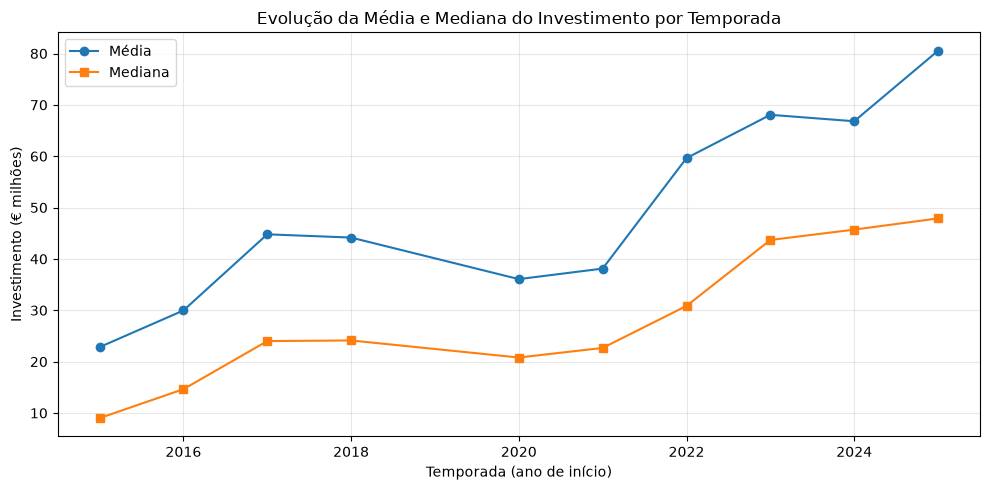

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
evolucao = base_final.groupby("season_start_year")["total_investment_milhoes"].agg(["mean", "median"])
ax.plot(evolucao.index, evolucao["mean"], marker="o", label="Média")
ax.plot(evolucao.index, evolucao["median"], marker="s", label="Mediana")
ax.set_title("Evolução da Média e Mediana do Investimento por Temporada")
ax.set_xlabel("Temporada (ano de início)")
ax.set_ylabel("Investimento (€ milhões)")
ax.legend()
plt.tight_layout()
plt.show()


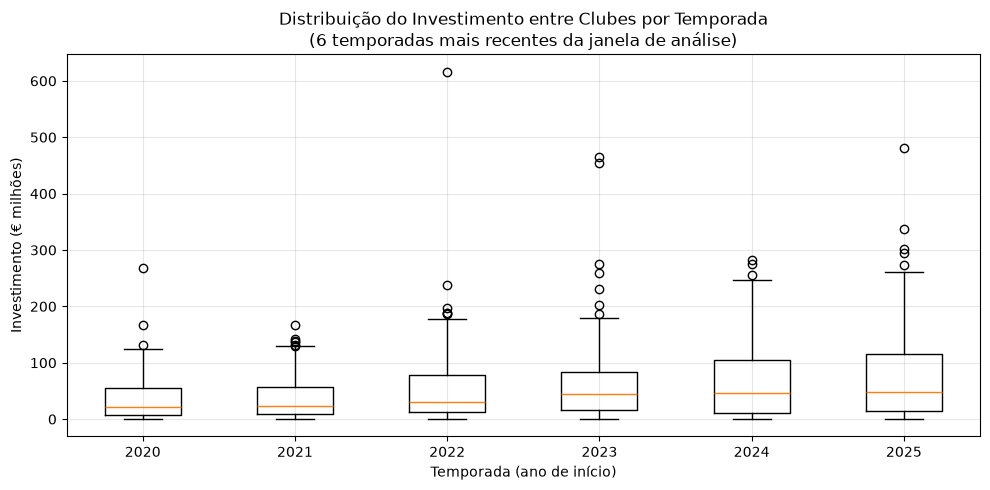

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
temporadas_recentes = sorted(base_final["season_start_year"].unique())[-6:]
dados_boxplot = [base_final.loc[base_final["season_start_year"] == t, "total_investment_milhoes"].dropna() for t in temporadas_recentes]
try:
    ax.boxplot(dados_boxplot, tick_labels=temporadas_recentes, showfliers=True)
except TypeError:  # compatibilidade com versões antigas do Matplotlib
    ax.boxplot(dados_boxplot, labels=temporadas_recentes, showfliers=True)
ax.set_title("Distribuição do Investimento entre Clubes por Temporada\n(6 temporadas mais recentes da janela de análise)")
ax.set_xlabel("Temporada (ano de início)")
ax.set_ylabel("Investimento (€ milhões)")
plt.tight_layout()
plt.show()


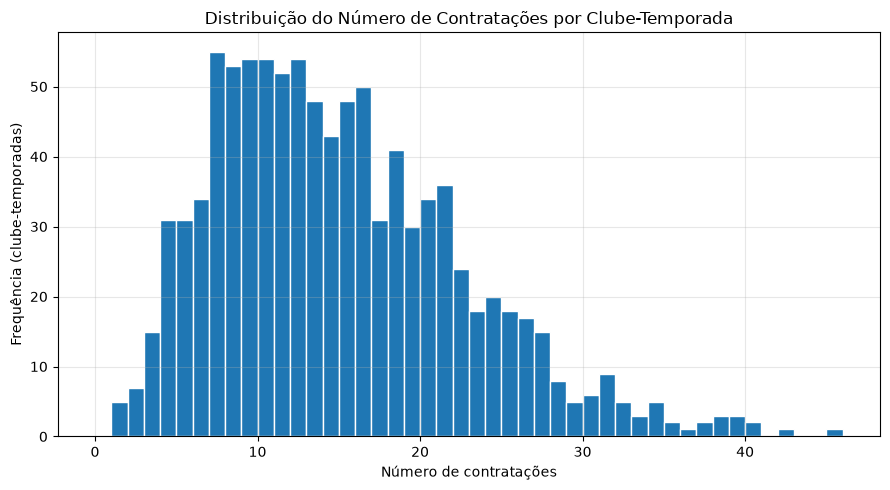

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(base_final["number_of_signings"].dropna(), bins=range(0, int(base_final["number_of_signings"].max()) + 2), edgecolor="white")
ax.set_title("Distribuição do Número de Contratações por Clube-Temporada")
ax.set_xlabel("Número de contratações")
ax.set_ylabel("Frequência (clube-temporadas)")
plt.tight_layout()
plt.show()


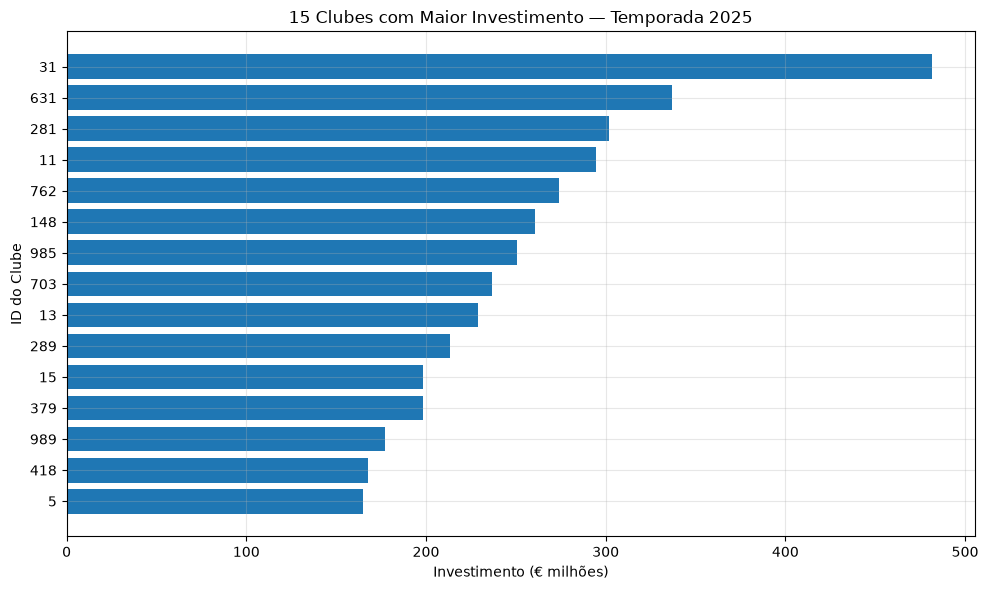

In [34]:
ultima_temporada = base_final["season_start_year"].max()
top_investidores = base_final[base_final["season_start_year"] == ultima_temporada].nlargest(15, "total_investment_milhoes")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_investidores["club_id"].astype(str), top_investidores["total_investment_milhoes"])
ax.set_title(f"15 Clubes com Maior Investimento — Temporada {ultima_temporada}")
ax.set_xlabel("Investimento (€ milhões)")
ax.set_ylabel("ID do Clube")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Resposta à Pergunta 1

Na base final (974 clube-temporadas), o investimento conhecido apresentou média de **€49,00 milhões** e mediana de **€24,18 milhões**. A média maior que a mediana, junto do desvio padrão de **€64,74 milhões**, do intervalo de **€0 a €616,25 milhões** e do percentil 90 de **€129,31 milhões**, indica uma distribuição assimétrica à direita, influenciada por poucos clubes com gastos muito elevados.

Para o número de contratações, a média foi **14,55**, a mediana **13** e a moda **7**; o desvio padrão foi **7,62** e a amplitude foi de **1 a 45** contratações. As médias de investimento por temporada variaram de €22,82 milhões (2015) a €80,55 milhões (2025), sempre em euros nominais.

**Hipótese 1: sustentada.** Os dados confirmam forte concentração do investimento e uma distribuição assimétrica. As estatísticas de investimento usam 972 observações com taxa conhecida; 2 clube-temporadas permaneceram com investimento totalmente desconhecido.

## 13. Pergunta 2 — Investimento x Desempenho Esportivo

**Pergunta:** Existe correlação entre o total investido em contratações por um clube em uma temporada e seu desempenho ao final da competição?

> **Atenção na leitura da posição final:** posição **1** é **melhor** que a posição **20**. Por isso, se investimento maior estiver associado a **melhor** posição, a correlação entre investimento e `final_position` tende a ser **negativa** (mais investimento → número de posição menor).


In [35]:
base_p2 = base_final.dropna(subset=["total_investment_milhoes"]).copy()
print("Clube-temporadas disponíveis para a Pergunta 2 (com investimento conhecido):", base_p2.shape[0])

display(base_p2[["points", "points_per_game", "goal_difference_per_game", "final_position"]].describe().round(2))


Clube-temporadas disponíveis para a Pergunta 2 (com investimento conhecido): 972


,points,points_per_game,goal_difference_per_game,final_position
count,972.00,972.00,972.00,972.00
mean,50.92,1.37,0.00,10.25
std,17.26,0.46,0.71,5.65
min,12.00,0.32,-1.82,1.00
25%,39.00,1.05,-0.45,5.00
50%,48.00,1.29,-0.11,10.00
75%,62.00,1.68,0.42,15.00
max,100.00,2.65,2.53,20.00


In [36]:
def correlacoes(df, col_x, col_y):
    pares = df.dropna(subset=[col_x, col_y])
    if len(pares) < 3:
        return np.nan, np.nan, np.nan, np.nan
    r_p, p_p = pearsonr(pares[col_x], pares[col_y])
    r_s, p_s = spearmanr(pares[col_x], pares[col_y])
    return r_p, p_p, r_s, p_s

pares_analisados = [
    ("total_investment_milhoes", "points_per_game"),
    ("total_investment_milhoes", "goal_difference_per_game"),
]
if posicao_disponivel:
    pares_analisados.append(("total_investment_milhoes", "final_position"))

linhas_resultado = []
for x, y in pares_analisados:
    r_p, p_p, r_s, p_s = correlacoes(base_p2, x, y)
    linhas_resultado.append({"variável_x": x, "variável_y": y, "pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s})

tabela_correlacao_geral = pd.DataFrame(linhas_resultado).round(3)
display(tabela_correlacao_geral)


,variável_x,variável_y,pearson_r,pearson_p,spearman_r,spearman_p
0,total_investment_milhoes,points_per_game,0.418,0.0,0.495,0.0
1,total_investment_milhoes,goal_difference_per_game,0.417,0.0,0.501,0.0
2,total_investment_milhoes,final_position,-0.373,0.0,-0.464,0.0


In [37]:
print("Correlação por liga (quando amostra suficiente, n >= 20):")
resultados_por_liga = []
for liga, grupo in base_p2.groupby("league_name"):
    if len(grupo) < 20:
        continue
    r_p, p_p, r_s, p_s = correlacoes(grupo, "total_investment_milhoes", "points_per_game")
    resultados_por_liga.append({"liga": liga, "n": len(grupo), "pearson_r": r_p, "spearman_r": r_s})

tabela_correlacao_por_liga = pd.DataFrame(resultados_por_liga).round(3)
display(tabela_correlacao_por_liga)


Correlação por liga (quando amostra suficiente, n >= 20):


,liga,n,pearson_r,spearman_r
0,Bundesliga,180,0.544,0.541
1,La Liga,200,0.573,0.512
2,Ligue 1,193,0.569,0.634
3,Premier League,199,0.341,0.413
4,Serie A,200,0.625,0.644


### Visualizações — Pergunta 2


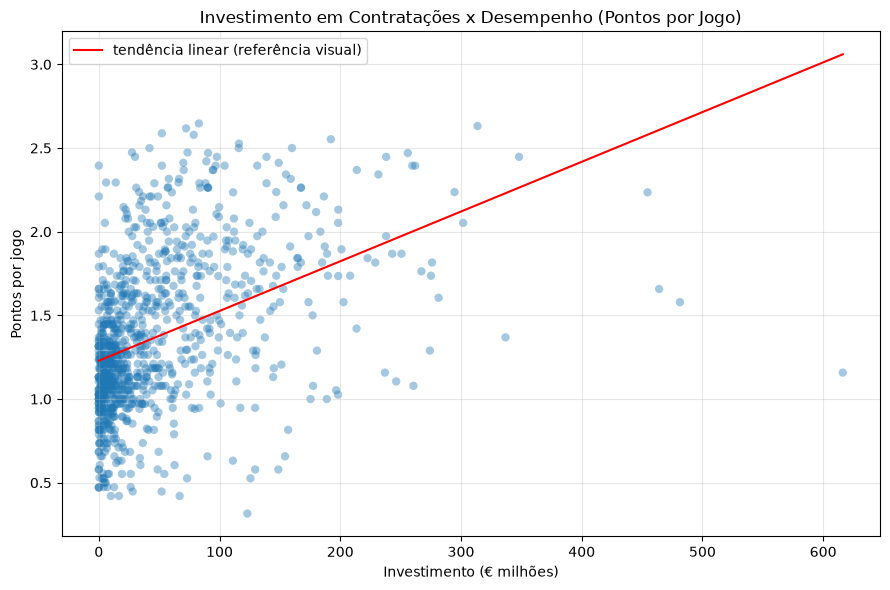

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(base_p2["total_investment_milhoes"], base_p2["points_per_game"], alpha=0.4, edgecolor="none")
z = np.polyfit(base_p2["total_investment_milhoes"], base_p2["points_per_game"], 1)
xs = np.linspace(base_p2["total_investment_milhoes"].min(), base_p2["total_investment_milhoes"].max(), 100)
ax.plot(xs, np.polyval(z, xs), color="red", linewidth=1.5, label="tendência linear (referência visual)")
ax.set_title("Investimento em Contratações x Desempenho (Pontos por Jogo)")
ax.set_xlabel("Investimento (€ milhões)")
ax.set_ylabel("Pontos por jogo")
ax.legend()
plt.tight_layout()
plt.show()


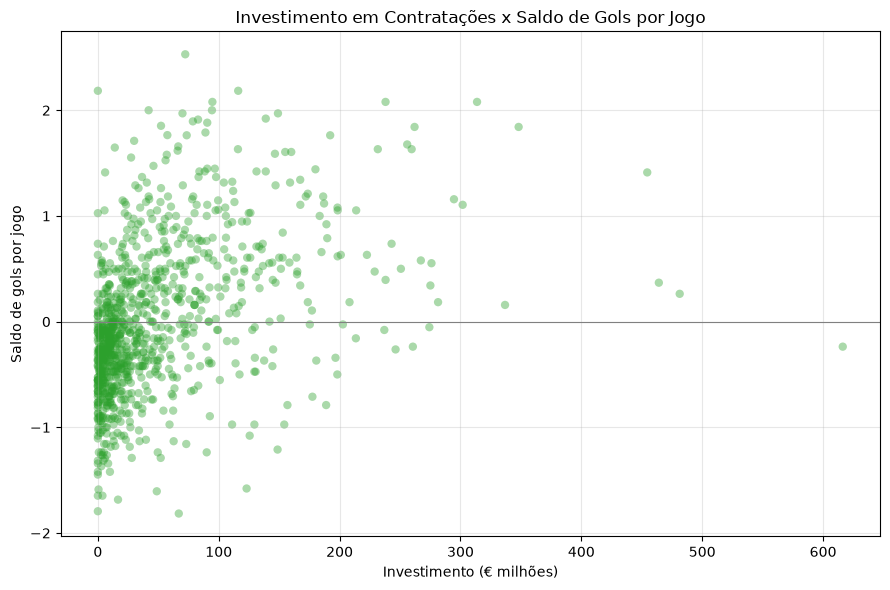

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(base_p2["total_investment_milhoes"], base_p2["goal_difference_per_game"], alpha=0.4, edgecolor="none", color="tab:green")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Investimento em Contratações x Saldo de Gols por Jogo")
ax.set_xlabel("Investimento (€ milhões)")
ax.set_ylabel("Saldo de gols por jogo")
plt.tight_layout()
plt.show()


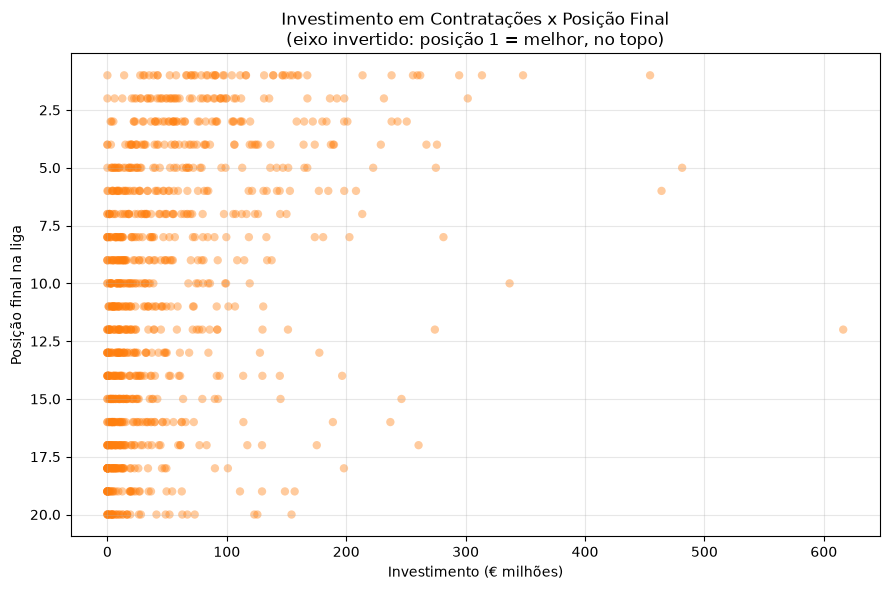

In [40]:
if posicao_disponivel:
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(base_p2["total_investment_milhoes"], base_p2["final_position"], alpha=0.4, edgecolor="none", color="tab:orange")
    ax.invert_yaxis()  # posição 1 (melhor) no topo do gráfico
    ax.set_title("Investimento em Contratações x Posição Final\n(eixo invertido: posição 1 = melhor, no topo)")
    ax.set_xlabel("Investimento (€ milhões)")
    ax.set_ylabel("Posição final na liga")
    plt.tight_layout()
    plt.show()
else:
    print("Gráfico de posição final não gerado - 'own_position' indisponível (ver limitação na Seção 9.5).")


### Resposta à Pergunta 2

Entre as 972 clube-temporadas com investimento conhecido, observamos associações positivas e estatisticamente significativas entre investimento e desempenho: pontos por jogo (Pearson **r = 0,418**, Spearman **r = 0,495**) e saldo de gols por jogo (Pearson **r = 0,417**, Spearman **r = 0,501**), com p < 0,001. Para a posição final, a associação foi negativa (Pearson **r = -0,373**, Spearman **r = -0,464**); o sinal negativo é coerente com posições menores representando melhor colocação.

As magnitudes são moderadas, e o espalhamento dos gráficos mostra que outros fatores também explicam o desempenho. Por liga, as correlações de pontos por jogo variaram de **0,341** (Premier League) a **0,625** (Serie A) no Pearson.

**Hipótese 2: sustentada como associação, não como causalidade.** O desenho exploratório e a correlação não permitem afirmar que gastar mais causa melhor desempenho.

## 14. Pergunta 3 — Desigualdade de Investimento x Desigualdade de Desempenho (por Liga-Temporada)

**Pergunta:** Ligas com maior desigualdade de investimento entre seus clubes também apresentam maior desigualdade de desempenho entre os times?

Aqui a unidade de análise muda de **clube-temporada** para **liga-temporada**. Para cada liga-temporada, calculamos a dispersão do investimento e do desempenho (`points_per_game`) entre os clubes.

> **Ordem correta da padronização (importante):** primeiro calculamos as medidas de dispersão (desvio padrão etc.) **dentro** de cada liga-temporada; só **depois** padronizamos, por Z-score, essas medidas de dispersão **entre** as liga-temporadas. Não padronizamos os clubes individualmente dentro de cada liga antes disso — isso faria o desvio padrão tender a 1 por construção e destruiria a informação que queremos comparar.


In [41]:
dispersao_liga_temporada = base_final.groupby(["league_name", "season_start_year"]).agg(
    n_clubes=("club_id", "nunique"),
    investment_mean=("total_investment_milhoes", "mean"),
    investment_std=("total_investment_milhoes", "std"),
    investment_var=("total_investment_milhoes", "var"),
    investment_range=("total_investment_milhoes", lambda s: s.max() - s.min()),
    performance_mean=("points_per_game", "mean"),
    performance_std=("points_per_game", "std"),
    performance_var=("points_per_game", "var"),
    performance_range=("points_per_game", lambda s: s.max() - s.min()),
).reset_index()

dispersao_liga_temporada["investment_cv"] = (dispersao_liga_temporada["investment_std"] / dispersao_liga_temporada["investment_mean"]).round(3)

print("Dispersão de investimento e desempenho por liga-temporada:")
display(dispersao_liga_temporada.round(3))


Dispersão de investimento e desempenho por liga-temporada:


,league_name,season_start_year,n_clubes,investment_mean,investment_std,investment_var,investment_range,performance_mean,performance_std,performance_var,performance_range,investment_cv
0,Bundesliga,2015,18,11.788,13.896,193.110,51.750,1.384,0.460,0.212,1.853,1.179
1,Bundesliga,2016,18,33.568,33.682,1134.494,110.750,1.379,0.410,0.168,1.676,1.003
2,Bundesliga,2017,18,29.698,31.163,971.145,118.390,1.364,0.411,0.169,1.824,1.049
3,Bundesliga,2018,18,24.705,17.438,304.071,61.630,1.381,0.500,0.250,1.735,0.706
4,Bundesliga,2020,18,20.328,22.641,512.617,71.000,1.368,0.444,0.198,1.824,1.114
5,Bundesliga,2021,18,27.669,33.358,1112.770,126.220,1.381,0.436,0.190,1.735,1.206
6,Bundesliga,2022,18,30.342,37.131,1378.688,145.865,1.377,0.408,0.167,1.235,1.224
7,Bundesliga,2023,18,47.396,57.263,3279.050,184.850,1.368,0.551,0.304,2.147,1.208
8,Bundesliga,2024,18,44.182,46.102,2125.386,148.600,1.374,0.447,0.200,1.676,1.043
9,Bundesliga,2025,18,51.314,53.800,2894.391,196.850,1.377,0.519,0.269,1.853,1.048


### Padronização por Z-score das medidas de dispersão

Como investimento (euros) e desempenho (pontos por jogo) estão em escalas completamente diferentes, padronizamos as **medidas de dispersão** (não os clubes individuais) para permitir comparação visual direta:

$$z = \frac{x - \bar{x}}{s}$$

onde $\bar{x}$ e $s$ são calculados **sobre o conjunto de liga-temporadas** (cada linha da tabela acima é uma observação). Interpretação: `z > 0` indica dispersão **acima da média** entre as liga-temporadas analisadas; `z < 0` indica dispersão **abaixo da média**.


In [42]:
def zscore(serie):
    return (serie - serie.mean()) / serie.std()

dispersao_liga_temporada["investment_dispersion_z"] = zscore(dispersao_liga_temporada["investment_std"])
dispersao_liga_temporada["performance_dispersion_z"] = zscore(dispersao_liga_temporada["performance_std"])

display(dispersao_liga_temporada[[
    "league_name", "season_start_year", "investment_std", "investment_dispersion_z",
    "performance_std", "performance_dispersion_z"
]].round(3))

print("\nVerificação: o desvio padrão dos Z-scores calculados aqui NÃO precisa ser exatamente 1,")
print("pois cada Z-score é individual; o que garantimos é que a MÉDIA e o DESVIO PADRÃO usados no cálculo")
print("vêm da distribuição das medidas de dispersão entre liga-temporadas, e não de uma padronização por clube.")


,league_name,season_start_year,investment_std,investment_dispersion_z,performance_std,performance_dispersion_z
0,Bundesliga,2015,13.896,-1.383,0.460,-0.191
1,Bundesliga,2016,33.682,-0.565,0.410,-1.256
2,Bundesliga,2017,31.163,-0.669,0.411,-1.227
3,Bundesliga,2018,17.438,-1.236,0.500,0.648
4,Bundesliga,2020,22.641,-1.021,0.444,-0.528
5,Bundesliga,2021,33.358,-0.578,0.436,-0.704
6,Bundesliga,2022,37.131,-0.423,0.408,-1.292
7,Bundesliga,2023,57.263,0.409,0.551,1.724
8,Bundesliga,2024,46.102,-0.052,0.447,-0.467
9,Bundesliga,2025,53.800,0.266,0.519,1.035



Verificação: o desvio padrão dos Z-scores calculados aqui NÃO precisa ser exatamente 1,
pois cada Z-score é individual; o que garantimos é que a MÉDIA e o DESVIO PADRÃO usados no cálculo
vêm da distribuição das medidas de dispersão entre liga-temporadas, e não de uma padronização por clube.


### Coeficiente de variação (medida complementar)

O **CV = desvio padrão / média** complementa a análise porque a desigualdade *relativa* de investimento pode ser mascarada por diferenças no nível médio de gastos entre as ligas (uma liga mais rica pode ter desvio padrão alto simplesmente porque todos os valores são grandes). O CV **não substitui** variância, desvio padrão e amplitude — é apenas um apoio interpretativo.


In [43]:
r_p_disp, p_p_disp = pearsonr(dispersao_liga_temporada["investment_std"], dispersao_liga_temporada["performance_std"])
r_s_disp, p_s_disp = spearmanr(dispersao_liga_temporada["investment_std"], dispersao_liga_temporada["performance_std"])

print("Correlação entre dispersão do investimento (desvio padrão) e dispersão do desempenho (desvio padrão), por liga-temporada:")
print(f"  Pearson  r = {r_p_disp:.3f} (p = {p_p_disp:.4f})")
print(f"  Spearman r = {r_s_disp:.3f} (p = {p_s_disp:.4f})")

r_p_cv, p_p_cv = pearsonr(dispersao_liga_temporada["investment_cv"], dispersao_liga_temporada["performance_std"])
print(f"\n(Complementar) Correlação entre CV do investimento e desvio padrão do desempenho: Pearson r = {r_p_cv:.3f} (p = {p_p_cv:.4f})")


Correlação entre dispersão do investimento (desvio padrão) e dispersão do desempenho (desvio padrão), por liga-temporada:
  Pearson  r = 0.072 (p = 0.6200)
  Spearman r = 0.165 (p = 0.2532)

(Complementar) Correlação entre CV do investimento e desvio padrão do desempenho: Pearson r = -0.278 (p = 0.0506)


### Visualização — Pergunta 3


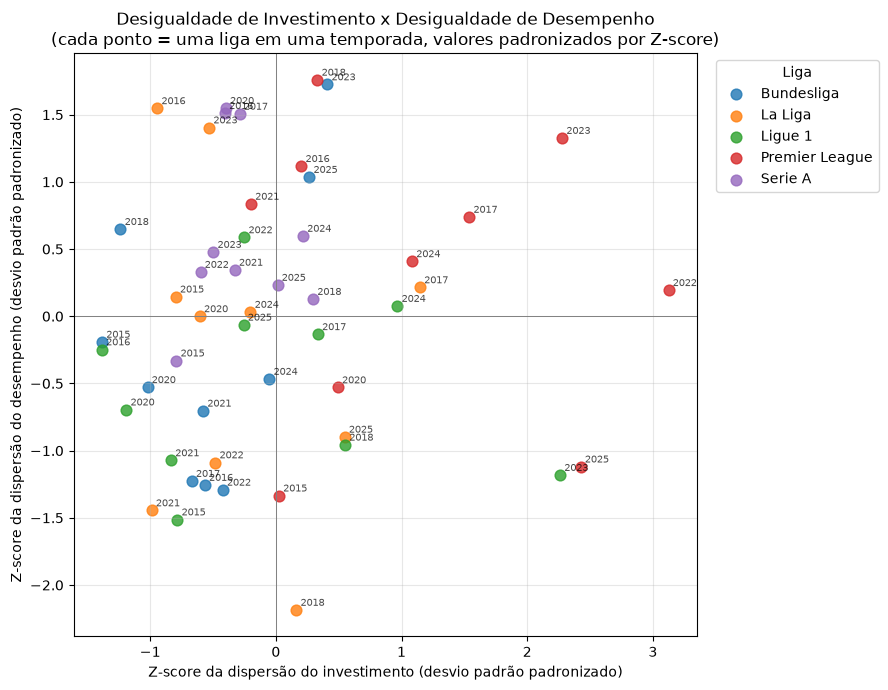

In [44]:
fig, ax = plt.subplots(figsize=(9, 7))
cores_por_liga = {liga: cor for liga, cor in zip(dispersao_liga_temporada["league_name"].unique(),
                                                   plt.cm.tab10.colors)}
for liga, grupo in dispersao_liga_temporada.groupby("league_name"):
    ax.scatter(grupo["investment_dispersion_z"], grupo["performance_dispersion_z"],
               label=liga, color=cores_por_liga[liga], s=60, alpha=0.8)

for _, linha in dispersao_liga_temporada.iterrows():
    ax.annotate(f"{linha['season_start_year']}", (linha["investment_dispersion_z"], linha["performance_dispersion_z"]),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")

ax.axhline(0, color="gray", linewidth=0.7)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_title("Desigualdade de Investimento x Desigualdade de Desempenho\n(cada ponto = uma liga em uma temporada, valores padronizados por Z-score)")
ax.set_xlabel("Z-score da dispersão do investimento (desvio padrão padronizado)")
ax.set_ylabel("Z-score da dispersão do desempenho (desvio padrão padronizado)")
ax.legend(title="Liga", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [45]:
print("Tabela-resumo por liga (médias das liga-temporadas na janela de análise):")
resumo_por_liga = dispersao_liga_temporada.groupby("league_name")[[
    "investment_mean", "investment_std", "investment_cv", "performance_mean", "performance_std"
]].mean().round(3)
display(resumo_por_liga.sort_values("investment_std", ascending=False))


Tabela-resumo por liga (médias das liga-temporadas na janela de análise):


,investment_mean,investment_std,investment_cv,performance_mean,performance_std
league_name,,,,,
Premier League,107.553,74.718,0.734,1.382,0.486
Ligue 1,31.823,45.945,1.478,1.373,0.445
La Liga,27.522,40.850,1.484,1.371,0.459
Serie A,44.359,40.626,0.967,1.371,0.500
Bundesliga,32.099,34.647,1.078,1.375,0.459


### Resposta à Pergunta 3

Nas 50 liga-temporadas analisadas, a correlação entre o desvio padrão do investimento e o desvio padrão dos pontos por jogo foi fraca e não significativa: Pearson **r = 0,072** (p = 0,620) e Spearman **r = 0,165** (p = 0,253). Portanto, não há evidência suficiente de que ligas com maior desigualdade de investimento apresentem também maior desigualdade de desempenho.

Como análise complementar, o coeficiente de variação do investimento apresentou correlação Pearson **r = -0,278** (p = 0,051) com a dispersão do desempenho — resultado limítrofe, que não altera a conclusão principal.

**Hipótese 3: não sustentada** para a medida principal de dispersão.

## 15. Limitações

- O dataset contém **35,12% de taxas de transferência desconhecidas** (`transfer_fee` ausente). Esses valores foram mantidos como `NaN`, enquanto o valor 0 foi preservado apenas para transferências registradas como gratuitas.
- A análise utiliza euros nominais, sem correção por inflação; comparações entre 2015 e 2025 devem ser interpretadas com cautela.
- A posição final foi aproximada pela posição registrada no último jogo cronológico disponível.
- Correlação não implica causalidade: desempenho também depende de elenco pré-existente, treinador, lesões, calendário e outros fatores não observados.
- A amostra está restrita às cinco grandes ligas e às dez temporadas completas mais recentes disponíveis em conjunto.

## 16. Conclusões

A análise encontrou uma distribuição de investimento fortemente assimétrica, com média (€49,00 milhões) superior à mediana (€24,18 milhões) e grande dispersão entre clubes. A quantidade de contratações também variou bastante, mas foi mais concentrada.

Houve associação positiva moderada entre investimento e pontos por jogo/saldo de gols por jogo, além de associação negativa moderada com a posição final. Isso responde parcialmente à pergunta "dinheiro compra desempenho?": clubes que investem mais tendem a apresentar melhores indicadores, mas os resultados não demonstram causalidade.

Por outro lado, a desigualdade de investimento entre ligas-temporadas não apresentou associação significativa com a desigualdade de desempenho. Assim: **Hipótese 1 sustentada; Hipótese 2 sustentada como associação; Hipótese 3 não sustentada**.